<a href="https://colab.research.google.com/github/divyamjariwal/Deep-Learning-Lab/blob/main/DL_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries

In [22]:
!pip install nltk -q

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from nltk.translate.bleu_score import sentence_bleu
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Uploading datset

In [23]:
uploaded = files.upload()

Saving spa.txt to spa (2).txt


loading Dataset

In [24]:
with open("spa.txt", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")

pairs = [line.split("\t") for line in lines]
pairs = [(en.lower(), sp.lower()) for en, sp in pairs]

print("Total dataset size:", len(pairs))

pairs = pairs[:30000]
print("Using subset size:", len(pairs))



Total dataset size: 118964
Using subset size: 30000


Dataset Info

In [25]:
df = pd.DataFrame(pairs, columns=["English","Spanish"])
display(df.head())

print("Total Sentence Pairs:", len(pairs))


,English,Spanish
0,go.,ve.
1,go.,vete.
2,go.,vaya.
3,go.,váyase.
4,hi.,hola.


Total Sentence Pairs: 30000


In [26]:
en_lengths = [len(p[0].split()) for p in pairs]
es_lengths = [len(p[1].split()) for p in pairs]

print("Average English Length:", np.mean(en_lengths))
print("Average Spanish Length:", np.mean(es_lengths))
print("Max English Length:", max(en_lengths))
print("Max Spanish Length:", max(es_lengths))

Average English Length: 3.704
Average Spanish Length: 3.5894
Max English Length: 7
Max Spanish Length: 12


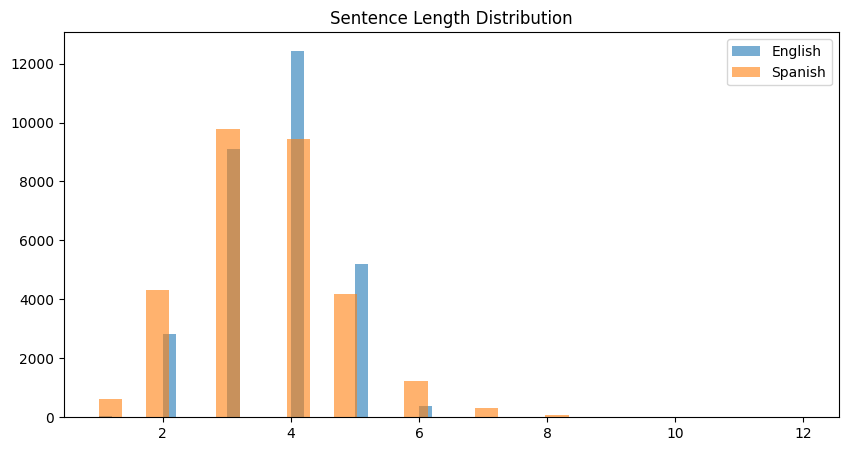

In [27]:
plt.figure(figsize=(10,5))
plt.hist(en_lengths, bins=30, alpha=0.6, label="English")
plt.hist(es_lengths, bins=30, alpha=0.6, label="Spanish")
plt.legend()
plt.title("Sentence Length Distribution")
plt.show()

In [28]:
random.shuffle(pairs)

n = len(pairs)
train = pairs[:int(0.8*n)]
val   = pairs[int(0.8*n):int(0.9*n)]
test  = pairs[int(0.9*n):]

Building Vocabulary

In [29]:
def build_vocab(sentences):
    counter = Counter()
    for s in sentences:
        counter.update(s.split())

    vocab = {"<pad>":0,"<sos>":1,"<eos>":2,"<unk>":3}
    for word in counter:
        vocab[word] = len(vocab)
    return vocab

src_vocab = build_vocab([x[0] for x in train])
tgt_vocab = build_vocab([x[1] for x in train])

inv_tgt_vocab = {v:k for k,v in tgt_vocab.items()}

print("English Vocabulary Size:", len(src_vocab))
print("Spanish Vocabulary Size:", len(tgt_vocab))

English Vocabulary Size: 7025
Spanish Vocabulary Size: 12449


Data Loaders

In [30]:
def encode(sentence, vocab):
    return [vocab.get(w, vocab["<unk>"]) for w in sentence.split()]

def add_tokens(seq):
    return [1] + seq + [2]

def collate_fn(batch):
    src_batch, tgt_batch = [], []

    for src, tgt in batch:
        src_seq = torch.tensor(add_tokens(encode(src, src_vocab)))
        tgt_seq = torch.tensor(add_tokens(encode(tgt, tgt_vocab)))
        src_batch.append(src_seq)
        tgt_batch.append(tgt_seq)

    src_batch = pad_sequence(src_batch, padding_value=0)
    tgt_batch = pad_sequence(tgt_batch, padding_value=0)

    return src_batch.to(device), tgt_batch.to(device)

train_loader = DataLoader(train, batch_size=64, shuffle=True, collate_fn=collate_fn)


setting parameters

In [31]:
INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(tgt_vocab)
EMB_DIM = 128
HIDDEN_DIM = 256
EPOCHS = 8

Encoder function

In [44]:
class SeqEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(embedded)
        return outputs, hidden, cell


Without attention

In [50]:
class SeqDecoderNoAtt(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden, cell):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        output,(hidden,cell)=self.lstm(embedded,(hidden,cell))
        prediction=self.fc(output.squeeze(0))
        return prediction, hidden, cell

Bahdanau Attention

In [54]:
class SeqDecoderBahdanau(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim + hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim*2, output_dim)

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, input, hidden, cell, encoder_outputs):

        input = input.unsqueeze(0)
        embedded = self.embedding(input)

        seq_len = encoder_outputs.shape[0]
        hidden_repeat = hidden.repeat(seq_len,1,1)

        energy = torch.tanh(
            self.W1(encoder_outputs) + self.W2(hidden_repeat)
        )

        attention = self.V(energy).squeeze(2)
        attention = torch.softmax(attention, dim=0)

        attention = attention.permute(1,0).unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1,0,2)

        context = torch.bmm(attention, encoder_outputs)
        context = context.permute(1,0,2)

        lstm_input = torch.cat((embedded, context), dim=2)
        output,(hidden,cell)=self.lstm(lstm_input,(hidden,cell))

        prediction = self.fc(
            torch.cat((output.squeeze(0),context.squeeze(0)),dim=1)
        )

        return prediction, hidden, cell, attention

Luong Attention

In [52]:
class SeqDecoderLuong(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.W = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, input, hidden, cell, encoder_outputs):

        input = input.unsqueeze(0)
        embedded = self.embedding(input)

        output,(hidden,cell)=self.lstm(embedded,(hidden,cell))

        encoder_outputs = encoder_outputs.permute(1,0,2)
        hidden_trans = self.W(hidden).permute(1,2,0)

        scores = torch.bmm(encoder_outputs, hidden_trans)
        attention = torch.softmax(scores, dim=1)

        context = torch.bmm(attention.transpose(1,2), encoder_outputs)
        context = context.permute(1,0,2)

        prediction = self.fc(
            torch.cat((output.squeeze(0),context.squeeze(0)),dim=1)
        )

        return prediction, hidden, cell, attention

Training Function

In [47]:
def train_basic(encoder, decoder):

    optimizer = optim.Adam(list(encoder.parameters()) +
                           list(decoder.parameters()))
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    losses = []

    for epoch in range(EPOCHS):

        epoch_loss = 0

        for src, tgt in train_loader:

            optimizer.zero_grad()
            encoder_outputs, hidden, cell = encoder(src)
            input = tgt[0]
            outputs = []

            for t in range(1, tgt.shape[0]):
                prediction, hidden, cell = decoder(input, hidden, cell)
                outputs.append(prediction)
                input = tgt[t]

            outputs = torch.stack(outputs)

            loss = criterion(
                outputs.reshape(-1, OUTPUT_DIM),
                tgt[1:].reshape(-1)
            )

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{EPOCHS} Loss: {epoch_loss:.3f}")

    return losses


In [48]:
def train_attention(encoder, decoder):

    optimizer = optim.Adam(list(encoder.parameters()) +
                           list(decoder.parameters()))
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    losses = []

    for epoch in range(EPOCHS):

        epoch_loss = 0

        for src, tgt in train_loader:

            optimizer.zero_grad()
            encoder_outputs, hidden, cell = encoder(src)
            input = tgt[0]
            outputs = []

            for t in range(1, tgt.shape[0]):
                prediction, hidden, cell, _ = decoder(
                    input, hidden, cell, encoder_outputs
                )
                outputs.append(prediction)
                input = tgt[t]

            outputs = torch.stack(outputs)

            loss = criterion(
                outputs.reshape(-1, OUTPUT_DIM),
                tgt[1:].reshape(-1)
            )

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{EPOCHS} Loss: {epoch_loss:.3f}")

    return losses


Calculating loss for no attention

In [53]:
# No Attention
enc1 = SeqEncoder(INPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
dec1 = SeqDecoderNoAtt(OUTPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
loss_no = train_basic(enc1, dec1)



Epoch 1/8 Loss: 2094.591
Epoch 2/8 Loss: 1623.070
Epoch 3/8 Loss: 1319.857
Epoch 4/8 Loss: 1094.386
Epoch 5/8 Loss: 913.835
Epoch 6/8 Loss: 759.904
Epoch 7/8 Loss: 628.564
Epoch 8/8 Loss: 516.383


AttributeError: 'super' object has no attribute '_init_'

Calculating Loss for Bahdanau and Luong

In [55]:
# Bahdanau
enc2 = SeqEncoder(INPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
dec2 = SeqDecoderBahdanau(OUTPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
loss_bah = train_attention(enc2, dec2)

# Luong
enc3 = SeqEncoder(INPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
dec3 = SeqDecoderLuong(OUTPUT_DIM, EMB_DIM, HIDDEN_DIM).to(device)
loss_luong = train_attention(enc3, dec3)

Epoch 1/8 Loss: 1911.768
Epoch 2/8 Loss: 1169.290
Epoch 3/8 Loss: 743.636
Epoch 4/8 Loss: 472.457
Epoch 5/8 Loss: 314.952
Epoch 6/8 Loss: 231.908
Epoch 7/8 Loss: 181.267
Epoch 8/8 Loss: 148.966
Epoch 1/8 Loss: 1976.830
Epoch 2/8 Loss: 1283.785
Epoch 3/8 Loss: 863.314
Epoch 4/8 Loss: 591.746
Epoch 5/8 Loss: 420.682
Epoch 6/8 Loss: 326.801
Epoch 7/8 Loss: 265.247
Epoch 8/8 Loss: 223.327


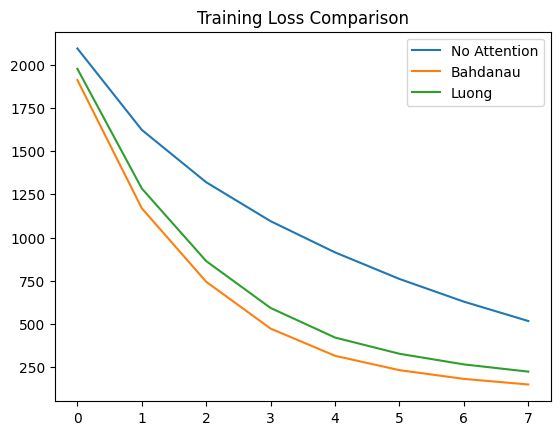

In [56]:
plt.plot(loss_no,label="No Attention")
plt.plot(loss_bah,label="Bahdanau")
plt.plot(loss_luong,label="Luong")
plt.legend()
plt.title("Training Loss Comparison")
plt.show()

BLEU SCORE CALCULATION

In [58]:
def compute_bleu(encoder, decoder, attention=False, samples=300):

    total = 0

    for src, tgt in test[:samples]:

        tokens = ["<sos>"] + src.split() + ["<eos>"]
        src_idx = [src_vocab.get(t, src_vocab["<unk>"]) for t in tokens]
        src_tensor = torch.LongTensor(src_idx).unsqueeze(1).to(device)

        with torch.no_grad():
            encoder_outputs, hidden, cell = encoder(src_tensor)

        trg_idx = [tgt_vocab["<sos>"]]

        for _ in range(20):
            trg_tensor = torch.LongTensor([trg_idx[-1]]).to(device)

            with torch.no_grad():
                if attention:
                    output, hidden, cell, _ = decoder(
                        trg_tensor, hidden, cell, encoder_outputs
                    )
                else:
                    output, hidden, cell = decoder(
                        trg_tensor, hidden, cell
                    )

            pred = output.argmax(1).item()
            trg_idx.append(pred)
            if pred == tgt_vocab["<eos>"]:
                break

        prediction = [inv_tgt_vocab[i] for i in trg_idx[1:-1]]
        reference = tgt.split()

        total += sentence_bleu([reference], prediction)

    return total / samples



In [59]:
bleu_no = compute_bleu(enc1, dec1, attention=False)
bleu_bah = compute_bleu(enc2, dec2, attention=True)
bleu_luong = compute_bleu(enc3, dec3, attention=True)

print("BLEU No Attention:", bleu_no)
print("BLEU Bahdanau:", bleu_bah)
print("BLEU Luong:", bleu_luong)

/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

BLEU No Attention: 0.027724131532416117
BLEU Bahdanau: 0.0506261295106023
BLEU Luong: 0.07519947095669076


Model Comparision

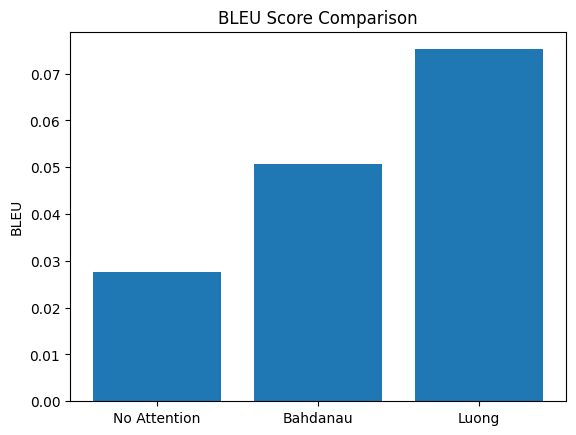

In [61]:
models = ["No Attention","Bahdanau","Luong"]
scores = [bleu_no, bleu_bah, bleu_luong]

plt.bar(models, scores)
plt.title("BLEU Score Comparison")
plt.ylabel("BLEU")
plt.show()